In [1]:
import mglearn
import pandas as pd
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('single_variable_data.csv')

In [3]:
df.head()

,risk_depression,risk_drug,risk_iadl,risk_health,risk_age,risk_housing_tenure,risk_unemployed,risk_subj_econ,risk_housing_safety,risk_housing_env,...,risk_smoke,risk_alcohol,risk_suicide,risk_network,risk_infra_gap,risk_aging_rate,risk_health_is_missing,risk_subj_econ_is_missing,risk_housing_env_is_missing,risk_digital_is_missing
0,0.000000,0.1,0.0,0.25,0.514286,0.0,1.0,0.25,0.1250,0.25,...,0.0,1.0,0.0,0.333333,0.621723,0.310723,0,0,0,0
1,0.333333,0.2,0.0,0.75,0.371429,1.0,1.0,0.75,0.6250,0.75,...,0.0,0.0,0.0,0.500000,0.621723,0.310723,0,0,0,0
2,0.133333,0.1,0.0,0.75,0.057143,0.0,0.0,0.75,0.6250,0.50,...,1.0,0.0,0.0,0.333333,0.621723,0.310723,0,0,0,0
3,0.133333,0.0,0.0,0.50,0.571429,0.0,1.0,0.25,0.5000,0.25,...,0.0,0.0,0.0,0.333333,0.621723,0.310723,0,0,0,0
4,0.800000,0.5,0.0,0.75,0.571429,1.0,1.0,0.75,0.5625,0.75,...,0.0,1.0,0.0,0.000000,0.621723,0.310723,0,0,0,0


In [39]:
# 1. health risk
health_risk = pd.DataFrame({'health_risk': df['risk_depression']*0.3 +df['risk_drug']*0.25+df['risk_iadl']*0.2+df['risk_health']*0.15+df['risk_age']*0.1})
health_risk.head()

,health_risk
0,0.113929
1,0.299643
2,0.183214
3,0.172143
4,0.534643


In [30]:
# 2. infra gap
infra_gap = df[['risk_infra_gap']].rename(columns={'risk_infra_gap':'infra_gap'})
infra_gap.head()

,infra_gap
0,0.621723
1,0.621723
2,0.621723
3,0.621723
4,0.621723


In [31]:
# 3. 고령화율
aging_rate = df[['risk_aging_rate']].rename(columns={'risk_aging_rate':'aging_rate'})
aging_rate.head()

,aging_rate
0,0.310723
1,0.310723
2,0.310723
3,0.310723
4,0.310723


In [34]:
# 4. 경제적 빈곤 및 불안정성
economic_instability = pd.DataFrame({'economic_instability': df['risk_housing_tenure']*0.4 + df['risk_unemployed']*0.2 + df['risk_subj_econ']*0.4})
economic_instability.head()

,economic_instability
0,0.3
1,0.9
2,0.3
3,0.3
4,0.9


In [35]:
# 5. 주거 및 생활 환경
living_conditions = pd.DataFrame({'living_conditions': df['risk_housing_safety']*0.6 + df['risk_housing_env']*0.4})
living_conditions.head()

,living_conditions
0,0.1750
1,0.6750
2,0.5750
3,0.4000
4,0.6375


In [36]:
# 6. 사회적 활동 및 정보 접근성 
social_activities = pd.DataFrame({'social_activities': df['risk_group']*0.25 + df['risk_digital']*0.35 + df['risk_meet']*0.4})
social_activities.head()

,social_activities
0,0.215833
1,0.912500
2,0.383333
3,0.563333
4,0.600000


In [37]:
# 7. 자기 방임 및 건강 행태 
self_care_deficit = pd.DataFrame({'self_care_deficit': df['risk_nutrition']*0.5 + df['risk_smoke']*0.15 + df['risk_alcohol']*0.35})
self_care_deficit.head()

,self_care_deficit
0,0.35
1,0.00
2,0.15
3,0.00
4,0.60


In [38]:
# 8. 심리적 절망감
despair = pd.DataFrame({'despair': df['risk_suicide']*0.5 + df['risk_network']*0.15})
despair.head()

,despair
0,0.050
1,0.075
2,0.050
3,0.050
4,0.000


In [41]:
arbitrary_weighted_df = pd.concat(
    [health_risk, infra_gap, aging_rate, economic_instability, living_conditions, social_activities, self_care_deficit, despair],
    axis=1
)
arbitrary_weighted_df.head()

,health_risk,infra_gap,aging_rate,economic_instability,living_conditions,social_activities,self_care_deficit,despair
0,0.113929,0.621723,0.310723,0.3,0.1750,0.215833,0.35,0.050
1,0.299643,0.621723,0.310723,0.9,0.6750,0.912500,0.00,0.075
2,0.183214,0.621723,0.310723,0.3,0.5750,0.383333,0.15,0.050
3,0.172143,0.621723,0.310723,0.3,0.4000,0.563333,0.00,0.050
4,0.534643,0.621723,0.310723,0.9,0.6375,0.600000,0.60,0.000


In [43]:
from sklearn.metrics import silhouette_score

In [44]:
inertia_kmeans = []
sil_scores_kmeans = []
K_range = range(2,14)

for n_clusters in K_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    # n_init: initial centroid 변경횟수 
    # 없이 했다가 추가하니까 실루엣스코어 살짝씩 올랐음
    cluster_labels = kmeans.fit_predict(arbitrary_weighted_df)
    
    inertia_kmeans.append(kmeans.inertia_)
    sil_scores_kmeans.append(silhouette_score(arbitrary_weighted_df, cluster_labels))

In [45]:
inertia_kmeans 

[662.0030845249202,
 533.8657186722571,
 476.48011811017875,
 432.26479944491234,
 407.08274431327135,
 389.29428413141596,
 373.3603543461577,
 357.9317764865546,
 346.17686387611553,
 335.8344928534743,
 325.0766989492657,
 316.74180896840323]

In [46]:
sil_scores_kmeans 

[0.28233187579591634,
 0.24382094649001265,
 0.23191826815140057,
 0.21304278004708502,
 0.20278188625551818,
 0.1827004651998785,
 0.1722227456716539,
 0.1588007655459255,
 0.15700865942280318,
 0.15719864767124223,
 0.15368226598594992,
 0.15898744292030503]

In [48]:
import matplotlib.pyplot as plt

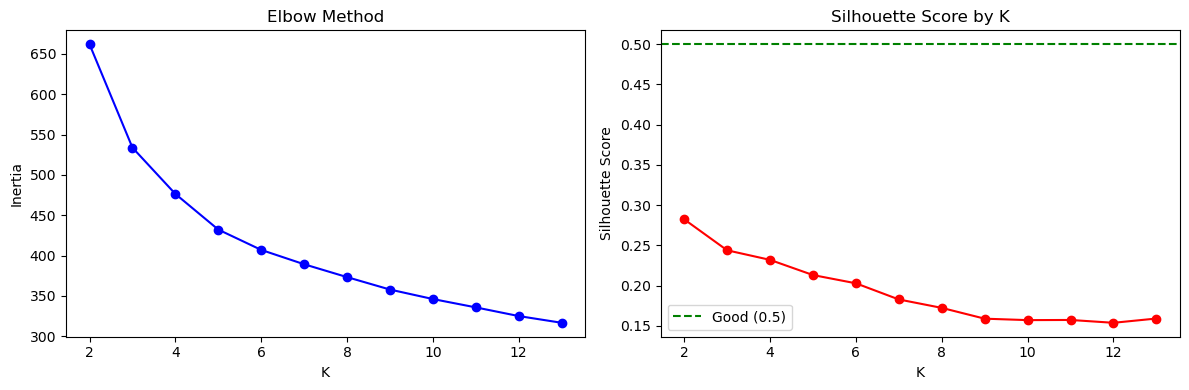

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia_kmeans, 'bo-')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores_kmeans, 'ro-')
axes[1].axhline(y=0.5, color='g', linestyle='--', label='Good (0.5)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].legend()
plt.tight_layout()
plt.show()